<a href="https://colab.research.google.com/github/Abhii-00/ai_ml_lab/blob/main/support_vector_machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [10]:
uploaded = files.upload()

Saving Titanic_Cleaned.csv to Titanic_Cleaned (1).csv


In [11]:
df = pd.read_csv("Titanic_Cleaned.csv")


In [12]:
print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())

   PassengerId  Survived  Pclass  \
0          1.0         0       3   
1          2.0         1       1   
2          3.0         1       3   
3          4.0         1       1   
4          5.0         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare    Cabin Embarked  FamilySize  
0      0         A/5 21171   7.2500  Unknown        S           2  
1      0          PC 17599  71.2833      C85        C           2  
2      0  STON/O2. 3101282   7.9250  Unknown        S           1  
3      0            113803  53.1000     C123    

In [13]:
df = pd.get_dummies(
    df,
    columns=['Sex', 'Embarked'],
    drop_first=True
)
print(df.head())

   PassengerId  Survived  Pclass  \
0          1.0         0       3   
1          2.0         1       1   
2          3.0         1       3   
3          4.0         1       1   
4          5.0         0       3   

                                                Name   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0      1      0   
2                             Heikkinen, Miss. Laina  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0      1      0   
4                           Allen, Mr. William Henry  35.0      0      0   

             Ticket     Fare    Cabin  FamilySize  Sex_male  Embarked_Q  \
0         A/5 21171   7.2500  Unknown           2      True       False   
1          PC 17599  71.2833      C85           2     False       False   
2  STON/O2. 3101282   7.9250  Unknown           1     False       False   
3            113803  53.10

In [14]:
df = df.drop(
    columns=['PassengerId', 'Name', 'Ticket', 'Cabin']
)

In [15]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [18]:
svm_model = SVC(
    kernel='rbf',
    random_state=42
)

In [19]:
svm_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [20]:
y_pred = svm_model.predict(X_test_scaled)

In [21]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8100558659217877
Accuracy (%): 81.00558659217877


In [22]:
print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.93      0.86       110
           1       0.84      0.62      0.72        69

    accuracy                           0.81       179
   macro avg       0.82      0.78      0.79       179
weighted avg       0.81      0.81      0.80       179



In [23]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[102   8]
 [ 26  43]]


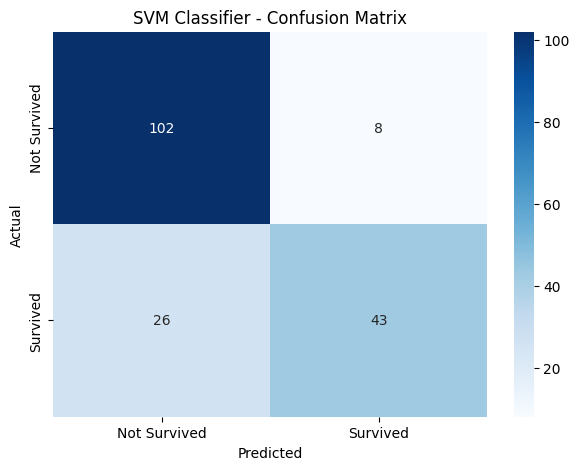

In [24]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Survived', 'Survived'],
    yticklabels=['Not Survived', 'Survived']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Classifier - Confusion Matrix")

plt.show()